In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error
from xgboost import XGBRegressor
from statsmodels.tsa.arima.model import ARIMA

df = pd.read_csv("../../data/staging/stg_walmart_demand.csv")
df["date"] = pd.to_datetime(df["date"])

df.head()

,store_id,department_id,date,weekly_sales_amount,isholiday,temperature,fuel_price,markdown1,markdown2,markdown3,markdown4,markdown5,cpi,unemployment,store_type,store_size,sku_id,location_id,demand_units
0,1,1,2010-02-05,24924.50,False,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,A,151315,SKU_001,STORE_001,249
1,1,1,2010-02-12,46039.49,True,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106,A,151315,SKU_001,STORE_001,460
2,1,1,2010-02-19,41595.55,False,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106,A,151315,SKU_001,STORE_001,416
3,1,1,2010-02-26,19403.54,False,46.63,2.561,NaN,NaN,NaN,NaN,NaN,211.319643,8.106,A,151315,SKU_001,STORE_001,194
4,1,1,2010-03-05,21827.90,False,46.50,2.625,NaN,NaN,NaN,NaN,NaN,211.350143,8.106,A,151315,SKU_001,STORE_001,218


In [2]:
weekly = (
    df.groupby("date")["demand_units"]
    .sum()
    .reset_index()
    .sort_values("date")
)

weekly.head()

,date,demand_units
0,2010-02-05,497502
1,2010-02-12,483349
2,2010-02-19,482755
3,2010-02-26,439690
4,2010-03-05,468734


In [3]:
train = weekly.iloc[:-12]
test = weekly.iloc[-12:]

y_train = train["demand_units"]
y_test = test["demand_units"]

In [4]:
def evaluate_model(y_true, y_pred, model_name):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = mean_absolute_percentage_error(y_true, y_pred) * 100
    bias = np.mean(y_pred - y_true)

    return {
        "model": model_name,
        "rmse": rmse,
        "mape": mape,
        "bias": bias
    }

In [5]:
moving_avg_forecast = [y_train.tail(4).mean()] * len(test)

moving_avg_results = evaluate_model(
    y_test,
    moving_avg_forecast,
    "Moving Average"
)

moving_avg_results

{'model': 'Moving Average',
 'rmse': np.float64(15124.777364063908),
 'mape': 2.982594294355325,
 'bias': np.float64(-2615.5833333333335)}

In [6]:
arima_model = ARIMA(y_train, order=(2,1,2))
arima_fit = arima_model.fit()

arima_forecast = arima_fit.forecast(steps=len(test))

arima_results = evaluate_model(
    y_test,
    arima_forecast,
    "ARIMA"
)

arima_results

{'model': 'ARIMA',
 'rmse': np.float64(18987.052579496263),
 'mape': 3.321791774417898,
 'bias': np.float64(10614.607994381653)}

In [7]:
weekly_ml = weekly.copy()

weekly_ml["week"] = weekly_ml["date"].dt.isocalendar().week.astype(int)
weekly_ml["month"] = weekly_ml["date"].dt.month
weekly_ml["year"] = weekly_ml["date"].dt.year
weekly_ml["lag_1"] = weekly_ml["demand_units"].shift(1)
weekly_ml["lag_4"] = weekly_ml["demand_units"].shift(4)
weekly_ml["rolling_4"] = weekly_ml["demand_units"].shift(1).rolling(4).mean()

weekly_ml = weekly_ml.dropna()
weekly_ml.head()

,date,demand_units,week,month,year,lag_1,lag_4,rolling_4
4,2010-03-05,468734,9,3,2010,439690.0,497502.0,475824.00
5,2010-03-12,459238,10,3,2010,468734.0,483349.0,468632.00
6,2010-03-19,449869,11,3,2010,459238.0,482755.0,462604.25
7,2010-03-26,441341,12,3,2010,449869.0,439690.0,454382.75
8,2010-04-02,504237,13,4,2010,441341.0,468734.0,454795.50


In [8]:
train_ml = weekly_ml.iloc[:-12]
test_ml = weekly_ml.iloc[-12:]

features = ["week", "month", "year", "lag_1", "lag_4", "rolling_4"]

X_train = train_ml[features]
y_train_ml = train_ml["demand_units"]

X_test = test_ml[features]
y_test_ml = test_ml["demand_units"]

xgb_model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    random_state=42
)

xgb_model.fit(X_train, y_train_ml)

xgb_forecast = xgb_model.predict(X_test)

xgb_results = evaluate_model(
    y_test_ml,
    xgb_forecast,
    "XGBoost"
)

xgb_results

{'model': 'XGBoost',
 'rmse': np.float64(11042.176234782706),
 'mape': 1.9019389525055885,
 'bias': np.float64(-4199.596354166667)}

In [9]:
results = pd.DataFrame([
    moving_avg_results,
    arima_results,
    xgb_results
])

results.sort_values("mape")

,model,rmse,mape,bias
2,XGBoost,11042.176235,1.901939,-4199.596354
0,Moving Average,15124.777364,2.982594,-2615.583333
1,ARIMA,18987.052579,3.321792,10614.607994


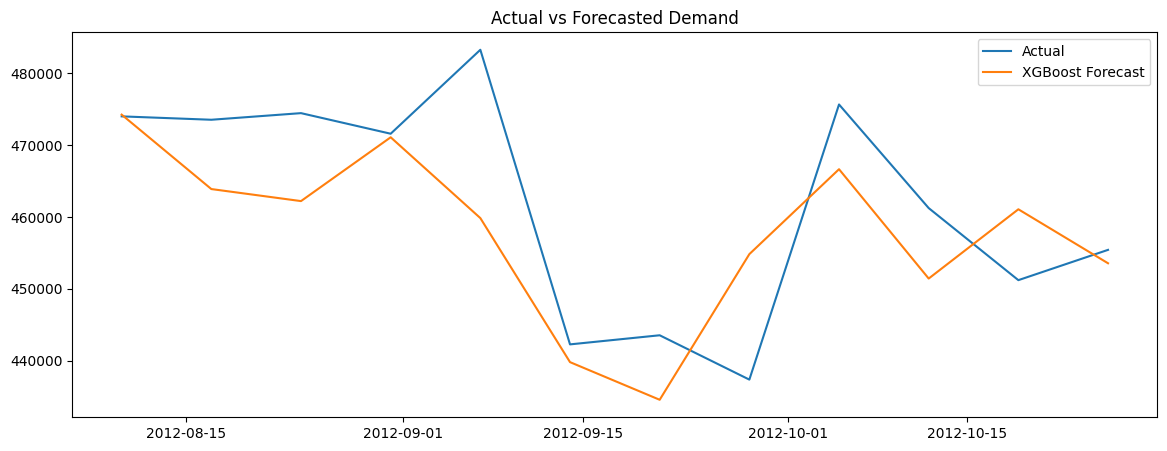

In [10]:
plt.figure(figsize=(14,5))
plt.plot(test_ml["date"], y_test_ml.values, label="Actual")
plt.plot(test_ml["date"], xgb_forecast, label="XGBoost Forecast")
plt.title("Actual vs Forecasted Demand")
plt.legend()
plt.show()

In [11]:
forecast_output = test_ml[["date"]].copy()
forecast_output["actual_demand"] = y_test_ml.values
forecast_output["forecast_demand"] = xgb_forecast

forecast_output.to_csv("../../data/processed/demand_forecast.csv", index=False)

forecast_output.head()

,date,actual_demand,forecast_demand
131,2012-08-10,474009,474251.06250
132,2012-08-17,473538,463887.71875
133,2012-08-24,474459,462211.96875
134,2012-08-31,471593,471096.21875
135,2012-09-07,483282,459845.56250
